<center>
<img src="https://www.fciencias.unam.mx/sites/default/files/logoFC_3.png" width = 800px>
</center>
<h1><center>Física Computacional: Práctica Temperatura diaria CDMX</center></h1>

**Profesora:** Dra. Roxana Mitzayé del Castillo Vázquez

**Ayudante:** Fis. Emiliano Montaño Gutiérrez


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [4]:
df_cdmx1 = pd.read_csv('./data/CDMX_2015_2020.csv')
df_cdmx2 = pd.read_csv('./data/CDMX_2020_2025.csv')

df_cuerna1 = pd.read_csv('./data/CUERNA_2015_2020.csv')
df_cuerna2 = pd.read_csv('./data/CUERNA_2020_2025.csv')

df_puebla1 = pd.read_csv('./data/PUEBLA_2015_2020.csv')
df_puebla2 = pd.read_csv('./data/PUEBLA_2020_2025.csv')

In [5]:
df_cdmx1 = df_cdmx1[df_cdmx1['DATE'] < '2020-01-01'] # delimitamos las fechas

df_cdmx = pd.concat([df_cdmx1, df_cdmx2])            # concatenamos data
df_cdmx = df_cdmx.sort_values(by = 'DATE')
df_cdmx = df_cdmx.reset_index()                     # corregimos indexdf_cdmx

df_cdmx.drop(['TMAX_ATTRIBUTES', 'TMIN_ATTRIBUTES'], axis = 1, inplace = True)
#df_cdmx.dropna(axis = 0, inplace = True)

In [6]:
df_cdmx

,index,STATION,NAME,DATE,TMAX,TMIN
0,103,MXM00076680,"MEXICO CITY, MX",2015-01-02,72.0,47.0
1,104,MXM00076680,"MEXICO CITY, MX",2015-01-05,68.0,44.0
2,105,MXM00076680,"MEXICO CITY, MX",2015-01-06,56.0,43.0
3,106,MXM00076680,"MEXICO CITY, MX",2015-01-08,69.0,46.0
4,107,MXM00076680,"MEXICO CITY, MX",2015-01-09,NaN,NaN
...,...,...,...,...,...,...
3465,1634,MXM00076680,"MEXICO CITY, MX",2025-11-25,76.0,54.0
3466,1635,MXM00076680,"MEXICO CITY, MX",2025-11-26,73.0,52.0
3467,1636,MXM00076680,"MEXICO CITY, MX",2025-11-27,68.0,55.0
3468,1637,MXM00076680,"MEXICO CITY, MX",2025-11-28,64.0,52.0


In [7]:
#plt.plot(df_cdmx['DATE'], df_cdmx['TMAX'], 'r')
#plt.plot(df_cdmx['DATE'], df_cdmx['TMIN'], 'b')

In [8]:
df_cdmx['TMAX'] = (df_cdmx['TMAX'] - 32)*(5/9)

In [9]:
df_cdmx['TMIN'] = (df_cdmx['TMIN'] - 32)*(5/9)

In [10]:
df_cdmx['DATE'][0].split(sep = '-')

['2015', '01', '02']

In [11]:
df_cdmx['YEAR'] = df_cdmx['DATE'].apply(lambda x: x.split(sep = '-')[0])

In [12]:
df_cdmx['MONTH'] = df_cdmx['DATE'].apply(lambda x: x.split(sep = '-')[1])

In [13]:
df_cdmx['DAY'] = df_cdmx['DATE'].apply(lambda x: x.split(sep = '-')[2])

In [14]:
df_cdmx

,index,STATION,NAME,DATE,TMAX,TMIN,YEAR,MONTH,DAY
0,103,MXM00076680,"MEXICO CITY, MX",2015-01-02,22.222222,8.333333,2015,01,02
1,104,MXM00076680,"MEXICO CITY, MX",2015-01-05,20.000000,6.666667,2015,01,05
2,105,MXM00076680,"MEXICO CITY, MX",2015-01-06,13.333333,6.111111,2015,01,06
3,106,MXM00076680,"MEXICO CITY, MX",2015-01-08,20.555556,7.777778,2015,01,08
4,107,MXM00076680,"MEXICO CITY, MX",2015-01-09,NaN,NaN,2015,01,09
...,...,...,...,...,...,...,...,...,...
3465,1634,MXM00076680,"MEXICO CITY, MX",2025-11-25,24.444444,12.222222,2025,11,25
3466,1635,MXM00076680,"MEXICO CITY, MX",2025-11-26,22.777778,11.111111,2025,11,26
3467,1636,MXM00076680,"MEXICO CITY, MX",2025-11-27,20.000000,12.777778,2025,11,27
3468,1637,MXM00076680,"MEXICO CITY, MX",2025-11-28,17.777778,11.111111,2025,11,28


In [15]:
df_cdmx_tmax = df_cdmx.drop(['TMIN'], axis = 1)
df_cdmx_tmax

,index,STATION,NAME,DATE,TMAX,YEAR,MONTH,DAY
0,103,MXM00076680,"MEXICO CITY, MX",2015-01-02,22.222222,2015,01,02
1,104,MXM00076680,"MEXICO CITY, MX",2015-01-05,20.000000,2015,01,05
2,105,MXM00076680,"MEXICO CITY, MX",2015-01-06,13.333333,2015,01,06
3,106,MXM00076680,"MEXICO CITY, MX",2015-01-08,20.555556,2015,01,08
4,107,MXM00076680,"MEXICO CITY, MX",2015-01-09,NaN,2015,01,09
...,...,...,...,...,...,...,...,...
3465,1634,MXM00076680,"MEXICO CITY, MX",2025-11-25,24.444444,2025,11,25
3466,1635,MXM00076680,"MEXICO CITY, MX",2025-11-26,22.777778,2025,11,26
3467,1636,MXM00076680,"MEXICO CITY, MX",2025-11-27,20.000000,2025,11,27
3468,1637,MXM00076680,"MEXICO CITY, MX",2025-11-28,17.777778,2025,11,28


In [16]:
df_cdmx_tmin = df_cdmx.drop(['TMAX'], axis = 1)
df_cdmx_tmin

,index,STATION,NAME,DATE,TMIN,YEAR,MONTH,DAY
0,103,MXM00076680,"MEXICO CITY, MX",2015-01-02,8.333333,2015,01,02
1,104,MXM00076680,"MEXICO CITY, MX",2015-01-05,6.666667,2015,01,05
2,105,MXM00076680,"MEXICO CITY, MX",2015-01-06,6.111111,2015,01,06
3,106,MXM00076680,"MEXICO CITY, MX",2015-01-08,7.777778,2015,01,08
4,107,MXM00076680,"MEXICO CITY, MX",2015-01-09,NaN,2015,01,09
...,...,...,...,...,...,...,...,...
3465,1634,MXM00076680,"MEXICO CITY, MX",2025-11-25,12.222222,2025,11,25
3466,1635,MXM00076680,"MEXICO CITY, MX",2025-11-26,11.111111,2025,11,26
3467,1636,MXM00076680,"MEXICO CITY, MX",2025-11-27,12.777778,2025,11,27
3468,1637,MXM00076680,"MEXICO CITY, MX",2025-11-28,11.111111,2025,11,28


In [17]:
df_cdmx_tmax_gr = df_cdmx_tmax.groupby(['YEAR', 'MONTH', 'DAY'])
df_cdmx_tmax_gr.max()

index      STATION             NAME        DATE       TMAX
YEAR MONTH DAY                                                            
2015 01    02     103  MXM00076680  MEXICO CITY, MX  2015-01-02  22.222222
           05     104  MXM00076680  MEXICO CITY, MX  2015-01-05  20.000000
           06     105  MXM00076680  MEXICO CITY, MX  2015-01-06  13.333333
           08     106  MXM00076680  MEXICO CITY, MX  2015-01-08  20.555556
           09     107  MXM00076680  MEXICO CITY, MX  2015-01-09        NaN
...               ...          ...              ...         ...        ...
2025 11    25    1634  MXM00076680  MEXICO CITY, MX  2025-11-25  24.444444
           26    1635  MXM00076680  MEXICO CITY, MX  2025-11-26  22.777778
           27    1636  MXM00076680  MEXICO CITY, MX  2025-11-27  20.000000
           28    1637  MXM00076680  MEXICO CITY, MX  2025-11-28  17.777778
           30    1638  MXM00076680  MEXICO CITY, MX  2025-11-30  22.222222

[3370 rows x 5 columns]

In [18]:
df_cdmx_tmin_gr = df_cdmx_tmin.groupby(['YEAR', 'MONTH', 'DAY'])
df_cdmx_tmin_gr.min() 

index      STATION             NAME        DATE       TMIN
YEAR MONTH DAY                                                            
2015 01    02     103  MXM00076680  MEXICO CITY, MX  2015-01-02   8.333333
           05     104  MXM00076680  MEXICO CITY, MX  2015-01-05   6.666667
           06     105  MXM00076680  MEXICO CITY, MX  2015-01-06   6.111111
           08     106  MXM00076680  MEXICO CITY, MX  2015-01-08   7.777778
           09     107  MXM00076680  MEXICO CITY, MX  2015-01-09        NaN
...               ...          ...              ...         ...        ...
2025 11    25    1634  MXM00076680  MEXICO CITY, MX  2025-11-25  12.222222
           26    1635  MXM00076680  MEXICO CITY, MX  2025-11-26  11.111111
           27    1636  MXM00076680  MEXICO CITY, MX  2025-11-27  12.777778
           28    1637  MXM00076680  MEXICO CITY, MX  2025-11-28  11.111111
           30    1638  MXM00076680  MEXICO CITY, MX  2025-11-30  11.666667

[3370 rows x 5 columns]

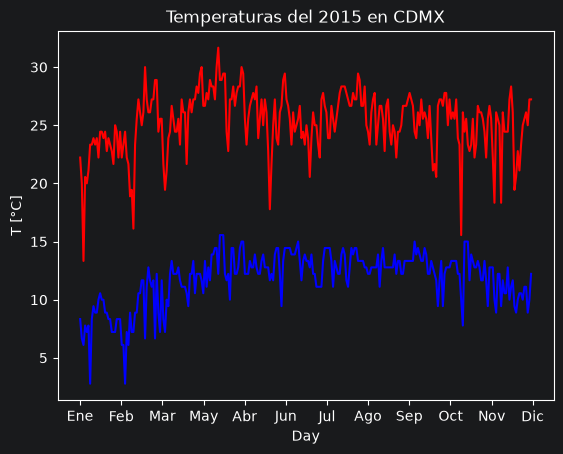

In [19]:
df = df_cdmx_tmax_gr.max().dropna(axis = 0)
df_max_2015 = df.loc[('2015', '01', '01'): ('2016', '01', '01')]

df = df_cdmx_tmin_gr.min().dropna(axis = 0)
df_min_2015 = df.loc[('2015', '01', '01'): ('2016', '01', '01')]

plt.plot(np.array(df_max_2015['TMAX']), 'r')
plt.plot(np.array(df_min_2015['TMIN']), 'b')

plt.title('Temperaturas del 2015 en CDMX')

plt.ylabel('T [°C]')
plt.xlabel('Day')

locs = np.linspace(0, len(df.loc[('2015', '01', '01'): ('2016', '01', '01')]), 12)
text = ['Ene', 'Feb', 'Mar', 'May', 'Abr', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

plt.xticks(locs, text)

plt.show()


TypeError: cannot unpack non-iterable Axes object

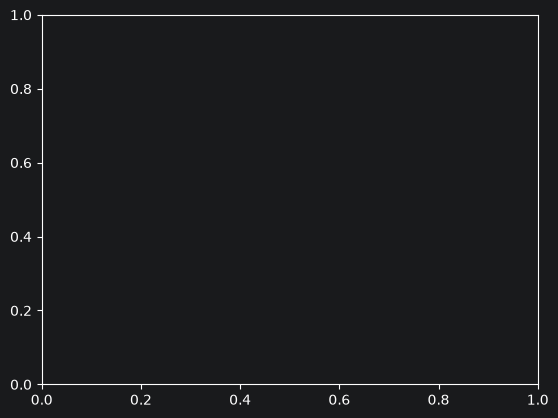

In [20]:
fig, ax = plt.subplot()

In [ ]:
#plt.plot(df_cdmx['DATE'], df_cdmx['TMAX'], 'r')
#plt.plot(df_cdmx['DATE'], df_cdmx['TMIN'], 'b')